In [1]:
import pandas as pd

df = pd.read_csv("Dataset_Modelo.csv", sep=";")
df.head()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3364\2948956416.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Dataset_Modelo.csv", sep=";")


,bgi_60_6,actividad,ingresos_formulario,cupo_solicitado,ciudad,edad,tasa_usura,numero_cambios_ultimos_6_meses,numero_cambios_email_ultimos_12_meses,numero_cambios_direccion_ultimos_12_meses,...,cliente_fintech,carga_financiera,ultm_sector,creditos_cerrados_deudorppal,huellas_consulta,meses_antiguedad_real,total_creditos_cerrados_financiero,creditos_vigentes_financiero,meses_antiguedad_financiero,cliente_antiguedad_todos_los_sectores
0,0,Independiente,4800000,1500000,YOPAL,60,"0,1877",0,0,0,...,0,"0,12",1,10,3,37,7,2,121,0
1,0,Independiente,1300000,2000000,CARTAGO,41,"0,1877",0,0,1,...,0,"0,13",1,0,1,0,0,2,109,0
2,0,Independiente,1500000,800000,MEDELLÍN,78,"0,1877",0,0,0,...,0,"0,06",3,10,0,121,0,0,0,0
3,0,Independiente,2700000,3200000,BOGOTÁ D.C.,49,"0,1877",0,0,0,...,0,"0,05",4,3,3,0,2,2,310,0
4,0,Independiente,1500000,1000000,MEDELLÍN,63,"0,1877",0,0,0,...,1,"0,06",3,32,2,163,0,1,257,0


In [2]:
df.shape


(235439, 30)

In [3]:
df.dtypes

bgi_60_6                                                   int64
actividad                                                 object
ingresos_formulario                                       object
cupo_solicitado                                            int64
ciudad                                                    object
edad                                                       int64
tasa_usura                                                object
numero_cambios_ultimos_6_meses                             int64
numero_cambios_email_ultimos_12_meses                      int64
numero_cambios_direccion_ultimos_12_meses                  int64
numero_cambios_direccion_ultimos_6_meses                   int64
numero_cambios_email_ultimos_6_meses                       int64
meses_apertura_ult_credito                                 int64
numero_cuentas_abiertas_ult_6_meses_sector_financiero      int64
numero_cuentas_abiertas_ult_6_meses_sector_real            int64
numero_cuentas_abiertas_u

In [4]:
df.columns

Index(['bgi_60_6', 'actividad', 'ingresos_formulario', 'cupo_solicitado',
       'ciudad', 'edad', 'tasa_usura', 'numero_cambios_ultimos_6_meses',
       'numero_cambios_email_ultimos_12_meses',
       'numero_cambios_direccion_ultimos_12_meses',
       'numero_cambios_direccion_ultimos_6_meses',
       'numero_cambios_email_ultimos_6_meses', 'meses_apertura_ult_credito',
       'numero_cuentas_abiertas_ult_6_meses_sector_financiero',
       'numero_cuentas_abiertas_ult_6_meses_sector_real',
       'numero_cuentas_abiertas_ult_6_meses_sector_cooperativo',
       'Participacion_cartera_sector_financiero',
       'Participacion_cartera_sector_cooperativo',
       'Participacion_cartera_sector_real', 'Estimador_ingresos',
       'cliente_fintech', 'carga_financiera', 'ultm_sector',
       'creditos_cerrados_deudorppal', 'huellas_consulta',
       'meses_antiguedad_real', 'total_creditos_cerrados_financiero',
       'creditos_vigentes_financiero', 'meses_antiguedad_financiero',
       'cli

In [5]:
df["bgi_60_6"].value_counts(dropna=False)

bgi_60_6
0    208757
1     26682
Name: count, dtype: int64

In [6]:
(26682 / 235439) * 100 # calculo mora temprana 

11.332871784198879

In [7]:
df["bgi_60_6"].mean() # calculo mora temmprana 

np.float64(0.1133287178419888)

In [9]:
df["carga_financiera"] = pd.to_numeric(
    df["carga_financiera"],
    errors="coerce"
)

In [10]:
df["carga_financiera"].isna().mean()

np.float64(0.9056655864151648)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3364\1510720363.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("bin_carga")


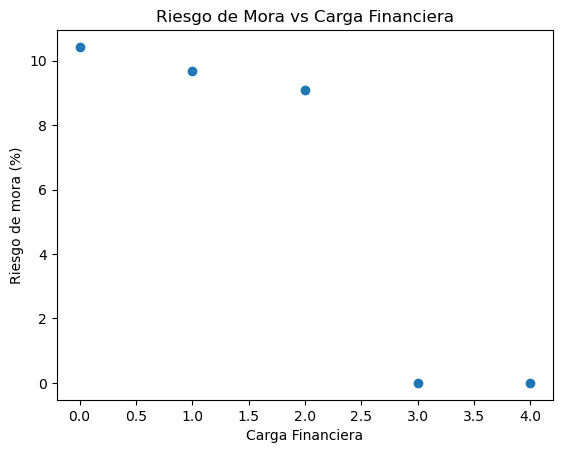

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

tmp = df[["carga_financiera", "bgi_60_6"]].dropna()

tmp["bin_carga"] = pd.cut(tmp["carga_financiera"], bins=100)

tabla = (
    tmp
    .groupby("bin_carga")
    .agg(
        riesgo_mora=("bgi_60_6", "mean"),
        carga_media=("carga_financiera", "mean"),
        n=("bgi_60_6", "size")
    )
    .reset_index()
)

plt.figure()
plt.plot(tabla["carga_media"], tabla["riesgo_mora"] * 100, marker="o")
plt.xlabel("Carga Financiera")
plt.ylabel("Riesgo de mora (%)")
plt.title("Riesgo de Mora vs Carga Financiera")
plt.show() # CALCULO CARGA FINANCIERA VS MORA TEMPRANA

In [15]:
tmp["bin"] = pd.cut(tmp["carga_financiera"], bins=40, include_lowest=True)

In [17]:
df["ingresos_formulario"].head(10)


0    4800000
1    1300000
2    1500000
3    2700000
4    1500000
5    1800000
6    2700000
7    7000000
8    4200000
9    2300000
Name: ingresos_formulario, dtype: object

In [18]:
df["ingresos_formulario"] = (
    df["ingresos_formulario"]
    .astype(str)
    .str.replace(r"[^0-9]", "", regex=True)  # deja solo números
)


In [19]:
df["ingresos_formulario"] = pd.to_numeric(df["ingresos_formulario"], errors="coerce")


In [24]:
SMV = 1300000

df["estimador_ingresos"] = df["ingresos_formulario"] / SMV


In [25]:
df["ingresos_formulario"] = (
    df["ingresos_formulario"]
    .astype(str)
    .str.replace(r"[^0-9]", "", regex=True)  # deja solo números
)
df["ingresos_formulario"] = pd.to_numeric(df["ingresos_formulario"], errors="coerce")
SMV = 1300000

df["estimador_ingresos"] = df["ingresos_formulario"] / SMV

In [26]:
df["ingresos_formulario"] = (
    df["ingresos_formulario"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["ingresos_formulario"] = pd.to_numeric(df["ingresos_formulario"], errors="coerce")


In [27]:
df["ingresos_formulario"].head(10)

0    4800000
1    1300000
2    1500000
3    2700000
4    1500000
5    1800000
6    2700000
7    7000000
8    4200000
9    2300000
Name: ingresos_formulario, dtype: int64

In [28]:
df[["ingresos_formulario","estimador_ingresos"]].head()


,ingresos_formulario,estimador_ingresos
0,4800000,3.692308
1,1300000,1.000000
2,1500000,1.153846
3,2700000,2.076923
4,1500000,1.153846


In [29]:
SMV = 1300000
df["estimador_ingresos"] = df["ingresos_formulario"] / SMV

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3364\1888770980.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  riesgo = df.groupby("bin_ingresos")["bgi_60_6"].mean().reset_index()


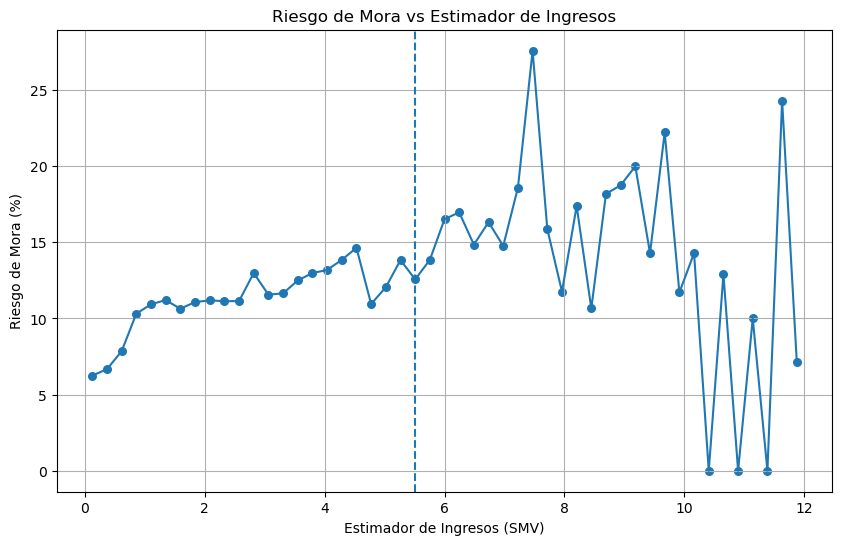

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Crear bins de ingresos
bins = np.linspace(0, 12, 50)
df["bin_ingresos"] = pd.cut(df["estimador_ingresos"], bins=bins)

# Calcular tasa de mora por bin
riesgo = df.groupby("bin_ingresos")["bgi_60_6"].mean().reset_index()
riesgo["x"] = riesgo["bin_ingresos"].apply(lambda x: x.mid)
riesgo["riesgo_mora"] = riesgo["bgi_60_6"] * 100

# Graficar
plt.figure(figsize=(10,6))
plt.plot(riesgo["x"], riesgo["riesgo_mora"])
plt.scatter(riesgo["x"], riesgo["riesgo_mora"], s=30)

plt.axvline(x=5.5, linestyle="--")  # donde empieza la volatilidad

plt.title("Riesgo de Mora vs Estimador de Ingresos")
plt.xlabel("Estimador de Ingresos (SMV)")
plt.ylabel("Riesgo de Mora (%)")
plt.grid(True)

plt.show() # CALCULO FINAL ESTIMADOR INGRESOS VS MORA


In [38]:
bins = np.linspace(0, 10, 120)

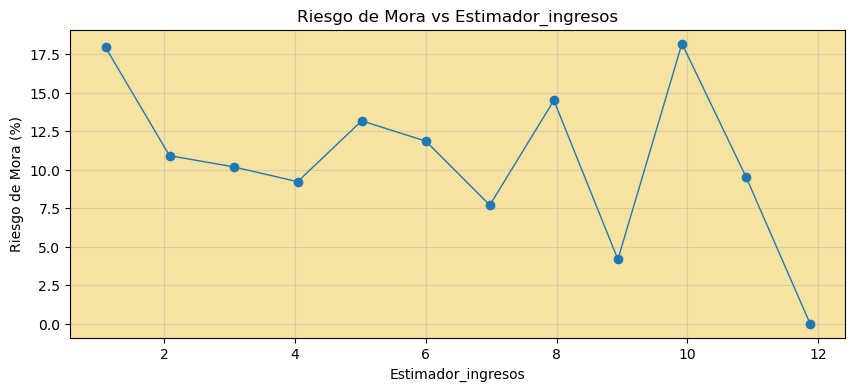

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

col = "Estimador_ingresos"  # ajusta si tu columna se llama distinto

tmp = df[[col, "bgi_60_6"]].copy()
tmp[col] = pd.to_numeric(tmp[col], errors="coerce")
tmp = tmp.dropna(subset=[col, "bgi_60_6"])

# bins como tu original
bins = np.linspace(0, 12, 50)
tmp["bin_ingresos"] = pd.cut(tmp[col], bins=bins, include_lowest=True)

riesgo = tmp.groupby("bin_ingresos", observed=True)["bgi_60_6"].mean().reset_index()

# midpoint del bin (como la presentacipon original)
riesgo["x"] = riesgo["bin_ingresos"].apply(lambda z: z.mid)

# quitar bins vacíos (NaN en riesgo)
riesgo = riesgo.dropna(subset=["x", "bgi_60_6"])
riesgo["riesgo_mora"] = riesgo["bgi_60_6"] * 100

# estilo Lina (amarillo + puntos)
plt.figure(figsize=(10, 4))
ax = plt.gca()
ax.set_facecolor("#f6e3a1")

plt.plot(riesgo["x"], riesgo["riesgo_mora"], marker="o", linewidth=1)
plt.title("Riesgo de Mora vs Estimador_ingresos")
plt.xlabel("Estimador_ingresos")
plt.ylabel("Riesgo de Mora (%)")
plt.grid(True, alpha=0.4)

plt.show()

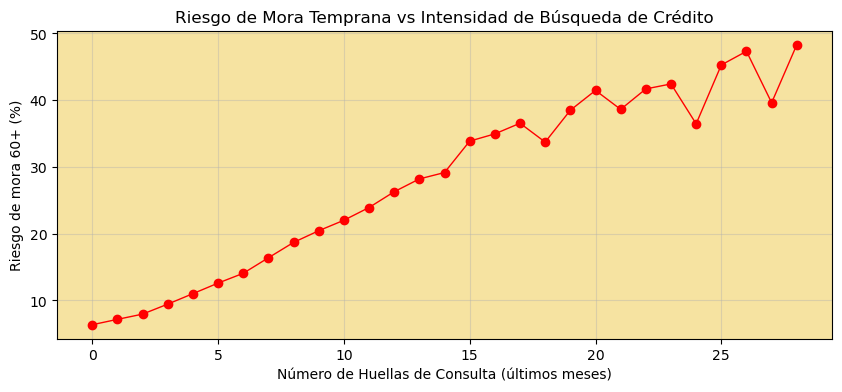

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Columnas
xcol = "huellas_consulta"
ycol = "bgi_60_6"

# 1) Preparar datos
tmp = df[[xcol, ycol]].copy()
tmp[xcol] = pd.to_numeric(tmp[xcol], errors="coerce")
tmp[ycol] = pd.to_numeric(tmp[ycol], errors="coerce")
tmp = tmp.dropna(subset=[xcol, ycol])

# 2) Quedarnos con huellas razonables (como en la gráfica de la presentación original, aprox 0 a 28)
tmp = tmp[(tmp[xcol] >= 0) & (tmp[xcol] <= 28)]

# 3) Si huellas es entero, lo graficamos por valor exacto (esto suele dar la curva definida)
riesgo = (
    tmp.groupby(xcol, observed=True)[ycol]
       .mean()
       .reset_index()
       .sort_values(xcol)
)

# 4) Convertir a porcentaje
riesgo["riesgo_mora"] = riesgo[ycol] * 100

# 5) Graficar estilo presentación original
plt.figure(figsize=(10, 4))
ax = plt.gca()
ax.set_facecolor("#f6e3a1")  # fondo amarillo

plt.plot(riesgo[xcol], riesgo["riesgo_mora"], marker="o", linewidth=1, color="red")
plt.title("Riesgo de Mora Temprana vs Intensidad de Búsqueda de Crédito")
plt.xlabel("Número de Huellas de Consulta (últimos meses)")
plt.ylabel("Riesgo de mora 60+ (%)")
plt.grid(True, alpha=0.4)

plt.show()

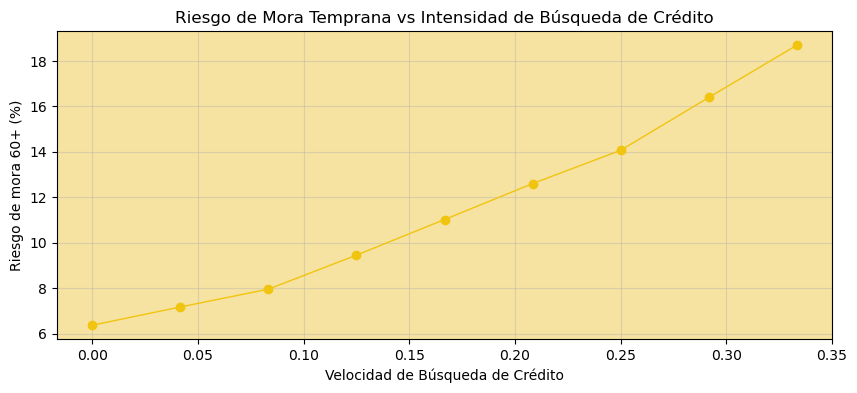

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Construir velocidad (ajusta meses_ventana si tu caso usa otro periodo)
meses_ventana = 24
df["velocidad_busqueda"] = df["huellas_consulta"] / meses_ventana

# 2) Preparar datos
xcol = "velocidad_busqueda"
ycol = "bgi_60_6"

tmp = df[[xcol, ycol]].copy()
tmp[xcol] = pd.to_numeric(tmp[xcol], errors="coerce")
tmp[ycol] = pd.to_numeric(tmp[ycol], errors="coerce")
tmp = tmp.dropna(subset=[xcol, ycol])

# 3) Acotar rango visual como la gráfica (0 a 0.35 aprox)
tmp = tmp[(tmp[xcol] >= 0) & (tmp[xcol] <= 0.35)]

# 4) Bins (para granulado)
bins = np.linspace(0, 0.35, 80)
tmp["bin_velocidad"] = pd.cut(tmp[xcol], bins=bins, include_lowest=True)

# 5) Riesgo por bin
riesgo = (
    tmp.groupby("bin_velocidad", observed=True)
       .agg(riesgo_mora=(ycol, "mean"), x=(xcol, "mean"), n=(ycol, "size"))
       .reset_index()
       .dropna(subset=["x", "riesgo_mora"])
       .sort_values("x")
)

# 6) Graficar estilo Lina
plt.figure(figsize=(10, 4))
ax = plt.gca()
ax.set_facecolor("#f6e3a1")

plt.plot(riesgo["x"], riesgo["riesgo_mora"] * 100, marker="o", linewidth=1, color="#f1c40f")
plt.title("Riesgo de Mora Temprana vs Intensidad de Búsqueda de Crédito")
plt.xlabel("Velocidad de Búsqueda de Crédito")
plt.ylabel("Riesgo de mora 60+ (%)")
plt.grid(True, alpha=0.4)
plt.show()

In [56]:
df["huellas_consulta"].nunique(), (df["huellas_consulta"]/24).nunique()

(76, 76)

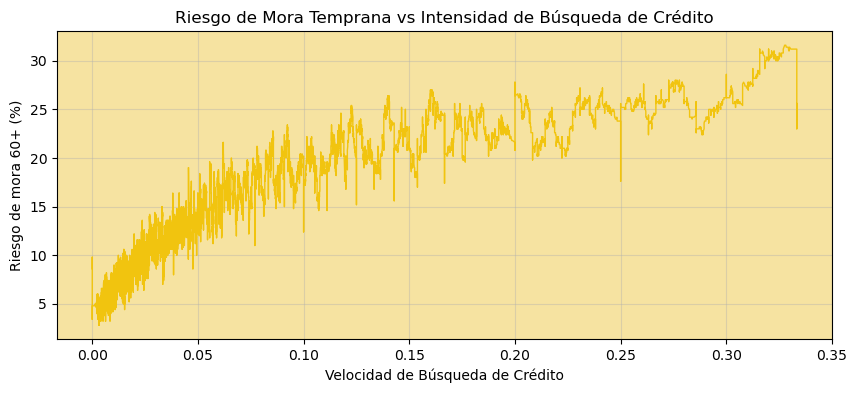

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Construir velocidad
df["velocidad_busqueda"] = df["huellas_consulta"] / (df["meses_antiguedad_financiero"] + 1)

# Preparar datos
tmp = df[["velocidad_busqueda", "bgi_60_6"]].dropna()
tmp = tmp[(tmp["velocidad_busqueda"] >= 0) & (tmp["velocidad_busqueda"] <= 0.35)]

# Ordenar por velocidad
tmp = tmp.sort_values("velocidad_busqueda")

# Rolling mean (ventana pequeña para granularidad)
window = 500   # prueba 300–800
tmp["riesgo_rolling"] = tmp["bgi_60_6"].rolling(window, center=True).mean()

# Graficar
plt.figure(figsize=(10, 4))
ax = plt.gca()
ax.set_facecolor("#f6e3a1")

plt.plot(
    tmp["velocidad_busqueda"],
    tmp["riesgo_rolling"] * 100,
    color="#f1c40f",
    linewidth=1
)

plt.title("Riesgo de Mora Temprana vs Intensidad de Búsqueda de Crédito")
plt.xlabel("Velocidad de Búsqueda de Crédito")
plt.ylabel("Riesgo de mora 60+ (%)")
plt.grid(True, alpha=0.4)
plt.show()

In [58]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [59]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [60]:
data = df.copy()
y = data["bgi_60_6"].astype(int)

In [61]:
data["ivc"] = (
    pd.to_numeric(data["huellas_consulta"], errors="coerce") /
    (pd.to_numeric(data["meses_antiguedad_financiero"], errors="coerce") + 1)
)

In [62]:
def to_num(series):
    s = series.astype(str).str.strip()
    s = s.str.replace("%", "", regex=False)
    s = s.str.replace(",", ".", regex=False)
    s = s.replace({"nan": np.nan, "None": np.nan, "": np.nan})
    return pd.to_numeric(s, errors="coerce")

cols_to_fix = [
    "ingresos_formulario", "tasa_usura",
    "Participacion_cartera_sector_financiero",
    "Participacion_cartera_sector_cooperativo",
    "Participacion_cartera_sector_real",
    "Estimador_ingresos", "carga_financiera"
]

for c in cols_to_fix:
    if c in data.columns:
        data[c] = to_num(data[c])

In [63]:
features = [
    "ivc",
    "ciudad", "actividad",
    "edad", "cupo_solicitado", "cliente_fintech", "ultm_sector",
    "huellas_consulta",
    "meses_antiguedad_financiero", "meses_antiguedad_real", "meses_apertura_ult_credito",
    "cliente_antiguedad_todos_los_sectores",
    "creditos_cerrados_deudorppal", "total_creditos_cerrados_financiero",
    "creditos_vigentes_financiero",
    "numero_cambios_ultimos_6_meses",
    "numero_cambios_email_ultimos_6_meses", "numero_cambios_email_ultimos_12_meses",
    "numero_cambios_direccion_ultimos_6_meses", "numero_cambios_direccion_ultimos_12_meses",
    "numero_cuentas_abiertas_ult_6_meses_sector_financiero",
    "numero_cuentas_abiertas_ult_6_meses_sector_real",
    "numero_cuentas_abiertas_ult_6_meses_sector_cooperativo",
    "Participacion_cartera_sector_financiero",
    "Participacion_cartera_sector_cooperativo",
    "Participacion_cartera_sector_real",
    "Estimador_ingresos", "ingresos_formulario", "carga_financiera", "tasa_usura"
]

features = [c for c in features if c in data.columns]
X = data[features]

In [64]:
cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

In [2]:
path = "Dataset_Modelo.csv"
with open(path, "r", encoding="utf-8", errors="replace") as f:
    for i, line in enumerate(f, start=1):
        if i == 8:
            print(line)

1;Pensionado;2700000;2000000;PIEDECUESTA;61;0,1877;0;0;0;0;0;8;0;0;0;0,13;0,27;0,6;2,6;0;0,24;3;15;0;113;2;1;192;1



In [3]:
import pandas as pd

df = pd.read_csv(
    "Dataset_Modelo.csv",
    sep=";",        # separador real de columnas
    decimal=",",    # separador decimal
    encoding="utf-8"
)

print(df.shape)
print(df.columns)

(235439, 30)
Index(['bgi_60_6', 'actividad', 'ingresos_formulario', 'cupo_solicitado',
       'ciudad', 'edad', 'tasa_usura', 'numero_cambios_ultimos_6_meses',
       'numero_cambios_email_ultimos_12_meses',
       'numero_cambios_direccion_ultimos_12_meses',
       'numero_cambios_direccion_ultimos_6_meses',
       'numero_cambios_email_ultimos_6_meses', 'meses_apertura_ult_credito',
       'numero_cuentas_abiertas_ult_6_meses_sector_financiero',
       'numero_cuentas_abiertas_ult_6_meses_sector_real',
       'numero_cuentas_abiertas_ult_6_meses_sector_cooperativo',
       'Participacion_cartera_sector_financiero',
       'Participacion_cartera_sector_cooperativo',
       'Participacion_cartera_sector_real', 'Estimador_ingresos',
       'cliente_fintech', 'carga_financiera', 'ultm_sector',
       'creditos_cerrados_deudorppal', 'huellas_consulta',
       'meses_antiguedad_real', 'total_creditos_cerrados_financiero',
       'creditos_vigentes_financiero', 'meses_antiguedad_financiero'

In [4]:
# Seleccionar variables
df_corr = df[["huellas_consulta", "bgi_60_6"]].dropna()

# Correlación de Pearson
corr = df_corr["huellas_consulta"].corr(df_corr["bgi_60_6"])

print("Correlación huellas vs mora:", corr)

Correlación huellas vs mora: 0.19420035729334728


In [5]:
import pandas as pd

df = pd.read_csv(
    "Dataset_Modelo.csv",
    sep=";",        # separador de columnas
    decimal=",",    # separador decimal
    encoding="utf-8"
)

print(df.shape)
print(df.columns)

(235439, 30)
Index(['bgi_60_6', 'actividad', 'ingresos_formulario', 'cupo_solicitado',
       'ciudad', 'edad', 'tasa_usura', 'numero_cambios_ultimos_6_meses',
       'numero_cambios_email_ultimos_12_meses',
       'numero_cambios_direccion_ultimos_12_meses',
       'numero_cambios_direccion_ultimos_6_meses',
       'numero_cambios_email_ultimos_6_meses', 'meses_apertura_ult_credito',
       'numero_cuentas_abiertas_ult_6_meses_sector_financiero',
       'numero_cuentas_abiertas_ult_6_meses_sector_real',
       'numero_cuentas_abiertas_ult_6_meses_sector_cooperativo',
       'Participacion_cartera_sector_financiero',
       'Participacion_cartera_sector_cooperativo',
       'Participacion_cartera_sector_real', 'Estimador_ingresos',
       'cliente_fintech', 'carga_financiera', 'ultm_sector',
       'creditos_cerrados_deudorppal', 'huellas_consulta',
       'meses_antiguedad_real', 'total_creditos_cerrados_financiero',
       'creditos_vigentes_financiero', 'meses_antiguedad_financiero'

In [6]:
# Seleccionar variables y eliminar nulos
df_corr = df[["carga_financiera", "bgi_60_6"]].dropna()

# Correlación de Pearson
corr_cf = df_corr["carga_financiera"].corr(df_corr["bgi_60_6"])

print("Correlación carga financiera vs mora:", corr_cf)

Correlación carga financiera vs mora: -0.0006547011558480947


In [8]:
# Normalizar huellas (IVC operativo)
df["ivc"] = df["huellas_consulta"] / df["huellas_consulta"].max()

# Calcular zona roja
zona_roja = df[df["ivc"] > 0.09]

# Porcentaje
porcentaje = len(zona_roja) / len(df)

print("Zona roja (%):", porcentaje)

Zona roja (%): 0.09228717417250328


In [9]:
len(df)

235439

In [11]:
# Buscar columnas que parezcan IVC/score/probabilidad
candidatas = [c for c in df.columns if any(k in c.lower() for k in ["ivc", "score", "prob", "proba", "riesgo", "risk"])]
candidatas


['ivc']

In [12]:
# Zona roja con el IVC real
zona_roja = df[df["ivc"] > 0.09]

print("Clientes zona roja:", len(zona_roja))
print("Zona roja (%):", len(zona_roja) / len(df))

Clientes zona roja: 21728
Zona roja (%): 0.09228717417250328


In [13]:
[c for c in df.columns if "cliente" in c.lower() or "%" in c]

['cliente_fintech', 'cliente_antiguedad_todos_los_sectores']

In [17]:
import pandas as pd
import numpy as np

# Definir bins según el slide
bins = [-np.inf, 0.02, 0.09, np.inf]
labels = ["VERDE", "AMARILLO", "ROJO"]

df["semaforo"] = pd.cut(df["ivc"], bins=bins, labels=labels)

In [18]:
tabla_semaforo = (
    df["semaforo"]
    .value_counts(normalize=True)
    .rename("%_clientes")
    .reset_index()
    .rename(columns={"index": "Semaforo"})
)

tabla_semaforo["%_clientes"] = tabla_semaforo["%_clientes"] * 100
tabla_semaforo # SLIDE PRINCIPALES DEBILIDADES IDENTIFICADAS - ZONA AMARILLA

,semaforo,%_clientes
0,AMARILLO,64.487192
1,VERDE,26.284091
2,ROJO,9.228717


In [19]:
df.head(5)

,bgi_60_6,actividad,ingresos_formulario,cupo_solicitado,ciudad,edad,tasa_usura,numero_cambios_ultimos_6_meses,numero_cambios_email_ultimos_12_meses,numero_cambios_direccion_ultimos_12_meses,...,ultm_sector,creditos_cerrados_deudorppal,huellas_consulta,meses_antiguedad_real,total_creditos_cerrados_financiero,creditos_vigentes_financiero,meses_antiguedad_financiero,cliente_antiguedad_todos_los_sectores,ivc,semaforo
0,0,Independiente,4800000.0,1500000,YOPAL,60,0.1877,0,0,0,...,1,10,3,37,7,2,121,0,0.030303,AMARILLO
1,0,Independiente,1300000.0,2000000,CARTAGO,41,0.1877,0,0,1,...,1,0,1,0,0,2,109,0,0.010101,VERDE
2,0,Independiente,1500000.0,800000,MEDELLÍN,78,0.1877,0,0,0,...,3,10,0,121,0,0,0,0,0.000000,VERDE
3,0,Independiente,2700000.0,3200000,BOGOTÁ D.C.,49,0.1877,0,0,0,...,4,3,3,0,2,2,310,0,0.030303,AMARILLO
4,0,Independiente,1500000.0,1000000,MEDELLÍN,63,0.1877,0,0,0,...,3,32,2,163,0,1,257,0,0.020202,AMARILLO


In [21]:
# Filtrar segmento ROJO
rojo = df[df["ivc"] > 0.09]

# Calcular tasa de mora
tasa_mora_rojo = rojo["bgi_60_6"].mean()

tasa_mora_rojo

np.float64(0.2760953608247423)

In [25]:
import numpy as np
import pandas as pd

# Definir semáforo según IVC
df["semaforo"] = np.select(
    [
        df["ivc"] > 0.09,
        (df["ivc"] >= 0.02) & (df["ivc"] <= 0.09),
        df["ivc"] < 0.02
    ],
    ["ROJO", "AMARILLO", "VERDE"],
    default="SIN CLASIFICAR"  # Added a string default value to match the data type of choices
)

In [27]:
import numpy as np
import pandas as pd

# Definir semáforo según IVC
df["semaforo"] = np.select(
    [
        df["ivc"] > 0.09,
        (df["ivc"] >= 0.02) & (df["ivc"] <= 0.09),
        df["ivc"] < 0.02
    ],
    ["ROJO", "AMARILLO", "VERDE"],
    default="SIN CLASIFICAR"  # Added a string default value to match the data type of choices
)

In [26]:
import numpy as np
import pandas as pd

# Definir semáforo según IVC
df["semaforo"] = np.select(
    [
        df["ivc"] > 0.09,
        (df["ivc"] >= 0.02) & (df["ivc"] <= 0.09),
        df["ivc"] < 0.02
    ],
    ["ROJO", "AMARILLO", "VERDE"],
    default="SIN CLASIFICAR"  # Added a string default value to match the data type of choices
)

In [28]:
import numpy as np

df["semaforo"] = np.select(
    [
        df["ivc"] > 0.09,
        (df["ivc"] >= 0.02) & (df["ivc"] <= 0.09),
        df["ivc"] < 0.02
    ],
    ["ROJO", "AMARILLO", "VERDE"],
    default="SIN_CLASIFICAR"   # 👈 clave para evitar el TypeError
)

In [29]:
df["semaforo"] = np.where(
    df["ivc"] > 0.09, "ROJO",
    np.where(df["ivc"] >= 0.02, "AMARILLO", "VERDE")
)

In [30]:
tabla = (df.groupby("semaforo")
           .agg(clientes=("ivc","count"),
                tasa_mora=("bgi_60_6","mean"))
           .assign(pct_clientes=lambda x: x["clientes"]/len(df),
                   pct_buenos=lambda x: 1-x["tasa_mora"])
        )

tabla[["pct_clientes","tasa_mora","pct_buenos"]] # SLIDE INSIGHT CRÍTICO: EL UMBRAL ES EL PROBLEMA

,pct_clientes,tasa_mora,pct_buenos
semaforo,,,
AMARILLO,0.644872,0.108353,0.891647
ROJO,0.092287,0.276095,0.723905
VERDE,0.262841,0.068387,0.931613


In [31]:
total_clientes = len(df)
total_clientes

235439

In [33]:
235439 * 0.092287

21727.958993

In [34]:
mora_base = df["bgi_60_6"].mean()
mora_base

np.float64(0.1133287178419888)

In [36]:
aprobados = df[df["ivc"] <= 0.09]   # lo que quedaría si rechazas ROJO
mora_post = aprobados["bgi_60_6"].mean()
mora_post

np.float64(0.09678023124687077)

In [11]:
import pandas as pd

df = pd.read_csv("Dataset_Modelo.csv", sep=";", engine="python")

print(df.columns.tolist())


['bgi_60_6', 'actividad', 'ingresos_formulario', 'cupo_solicitado', 'ciudad', 'edad', 'tasa_usura', 'numero_cambios_ultimos_6_meses', 'numero_cambios_email_ultimos_12_meses', 'numero_cambios_direccion_ultimos_12_meses', 'numero_cambios_direccion_ultimos_6_meses', 'numero_cambios_email_ultimos_6_meses', 'meses_apertura_ult_credito', 'numero_cuentas_abiertas_ult_6_meses_sector_financiero', 'numero_cuentas_abiertas_ult_6_meses_sector_real', 'numero_cuentas_abiertas_ult_6_meses_sector_cooperativo', 'Participacion_cartera_sector_financiero', 'Participacion_cartera_sector_cooperativo', 'Participacion_cartera_sector_real', 'Estimador_ingresos', 'cliente_fintech', 'carga_financiera', 'ultm_sector', 'creditos_cerrados_deudorppal', 'huellas_consulta', 'meses_antiguedad_real', 'total_creditos_cerrados_financiero', 'creditos_vigentes_financiero', 'meses_antiguedad_financiero', 'cliente_antiguedad_todos_los_sectores']


In [12]:
import pandas as pd
import numpy as np

df = pd.read_csv("Dataset_Modelo.csv", sep=";", engine="python")

# LIMPIAR NOMBRES DE COLUMNAS
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.lower()
)

print(df.columns)


Index(['bgi_60_6', 'actividad', 'ingresos_formulario', 'cupo_solicitado',
       'ciudad', 'edad', 'tasa_usura', 'numero_cambios_ultimos_6_meses',
       'numero_cambios_email_ultimos_12_meses',
       'numero_cambios_direccion_ultimos_12_meses',
       'numero_cambios_direccion_ultimos_6_meses',
       'numero_cambios_email_ultimos_6_meses', 'meses_apertura_ult_credito',
       'numero_cuentas_abiertas_ult_6_meses_sector_financiero',
       'numero_cuentas_abiertas_ult_6_meses_sector_real',
       'numero_cuentas_abiertas_ult_6_meses_sector_cooperativo',
       'participacion_cartera_sector_financiero',
       'participacion_cartera_sector_cooperativo',
       'participacion_cartera_sector_real', 'estimador_ingresos',
       'cliente_fintech', 'carga_financiera', 'ultm_sector',
       'creditos_cerrados_deudorppal', 'huellas_consulta',
       'meses_antiguedad_real', 'total_creditos_cerrados_financiero',
       'creditos_vigentes_financiero', 'meses_antiguedad_financiero',
       'cli

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# CARGA DEL DATASET
# ==============================
df = pd.read_csv("Dataset_Modelo.csv", sep=";", engine="python")

# ==============================
# CONSTRUCCIÓN DEL IVC
# ==============================
df["IVC"] = df["huellas_consulta"] / df["meses_antiguedad_real"].replace(0, np.nan)

# ==============================
# VARIABLES CLAVE
# ==============================
IVC_COL = "IVC"
TARGET_COL = "bgi_60_6"
MONTO_COL = "cupo_solicitado"

df = df[[IVC_COL, TARGET_COL, MONTO_COL]].dropna()

df.head()


,IVC,bgi_60_6,cupo_solicitado
0,0.081081,0,1500000
2,0.000000,0,800000
4,0.012270,0,1000000
5,0.181818,0,1500000
6,0.000000,1,2000000


In [15]:
MARGEN = 0.25   # margen promedio del crédito
LGD = 0.70      # pérdida dado default


In [16]:
def simular_umbral(df, umbral):
    segmento_rojo = df[IVC_COL] >= umbral

    volumen_total = df[MONTO_COL].sum()
    volumen_rojo = df.loc[segmento_rojo, MONTO_COL].sum()

    mora_rojo = df.loc[segmento_rojo, TARGET_COL].mean()

    ingreso_perdido = volumen_rojo * MARGEN
    perdida_evitable = volumen_rojo * mora_rojo * LGD

    return {
        "umbral": umbral,
        "pct_volumen": volumen_rojo / volumen_total,
        "mora_rojo": mora_rojo,
        "utilidad_neta": perdida_evitable - ingreso_perdido
    }


In [17]:
umbral_actual = 0.09

resultado = simular_umbral(df, umbral_actual)

pd.DataFrame([resultado]).round(3)


,umbral,pct_volumen,mora_rojo,utilidad_neta
0,0.09,0.26,0.194,-1.537821e+10


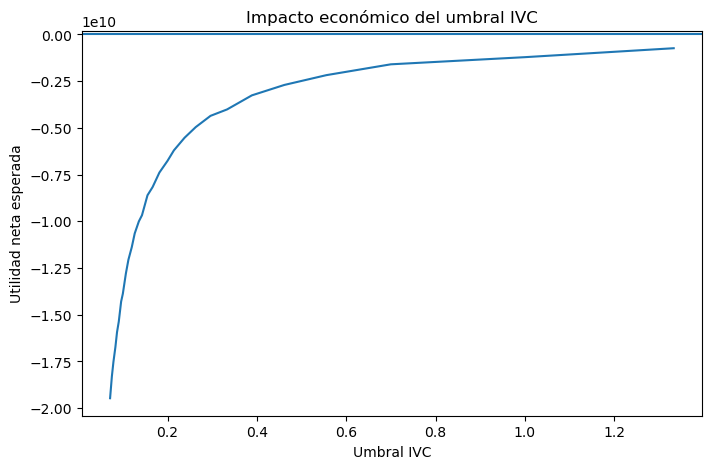

In [18]:
umbrales = np.percentile(df[IVC_COL], np.arange(70, 99))

resultados = pd.DataFrame(
    [simular_umbral(df, u) for u in umbrales]
)

plt.figure(figsize=(8,5))
plt.plot(resultados["umbral"], resultados["utilidad_neta"])
plt.axhline(0)
plt.xlabel("Umbral IVC")
plt.ylabel("Utilidad neta esperada")
plt.title("Impacto económico del umbral IVC")
plt.show()

# Para construir esta gráfica asumimos supuestos simples y transparentes de negocio. 
# Tomamos del dataset real el monto de los créditos y la mora observada, y usamos el 
# IVC únicamente para segmentar a los clientes que serían rechazados según el semáforo actual. Sobre ese volumen, 
# asumimos un margen promedio del 25% como ingreso cuando un crédito paga, y una pérdida dada la mora (LGD) del 70% cuando un cliente cae en default. 
# Con estos supuestos comparamos la pérdida que se evitaría al rechazar clientes riesgosos contra el ingreso que se dejaría de percibir al rechazar 
# clientes que sí habrían pagado. El resultado refleja impacto económico esperado, no una métrica estadística.
# Margen 25%:De cada peso que presta, Alkomprar espera ganar 25 centavos si el cliente paga normalmente.
# LGD 70%:Cuando un cliente cae en mora fuerte,en promedio se pierde el 70% del monto prestado.

# Qué demostramos con el análisis? Probamos en el dataset real qué pasa si aplicas esa regla:

# “Si IVC > 0.09 → rechazo automático” Y vimos que:
# Ese grupo es ~26–30% del volumen
# Tiene mora alta (~19%) 
# Pero la mayoría paga
# Rechazarlos destruye valor económico
# Por eso la utilidad sale negativa.


In [19]:
import numpy as np
import pandas as pd

# Rango amplio de umbrales posibles
umbrales = np.percentile(df[IVC_COL], np.arange(50, 99.5, 0.5))

resultados = pd.DataFrame(
    [simular_umbral(df, u) for u in umbrales]
)

# Umbral óptimo = máxima utilidad neta
optimo = resultados.loc[resultados["utilidad_neta"].idxmax()]

resultados.round(3)



,umbral,pct_volumen,mora_rojo,utilidad_neta
0,0.033,0.517,0.155,-3.781083e+10
1,0.034,0.509,0.156,-3.705732e+10
2,0.035,0.503,0.157,-3.653527e+10
3,0.035,0.498,0.157,-3.608663e+10
4,0.036,0.493,0.158,-3.559490e+10
...,...,...,...,...
94,1.000,0.030,0.247,-1.215136e+09
95,1.062,0.025,0.259,-8.854140e+08
96,1.333,0.020,0.258,-7.363918e+08
97,1.667,0.015,0.268,-4.825457e+08


In [20]:
optimo.round(3)

# El mejor umbral posible para rechazar es: IVC ≈ 2.17
# El modelo funciona como señal de riesgo, pero la acción asociada al rojo es incorrecta.
# No existe un umbral de rechazo automático que sea económicamente óptimo


umbral           2.167000e+00
pct_volumen      1.000000e-02
mora_rojo        2.760000e-01
utilidad_neta   -2.906054e+08
Name: 98, dtype: float64

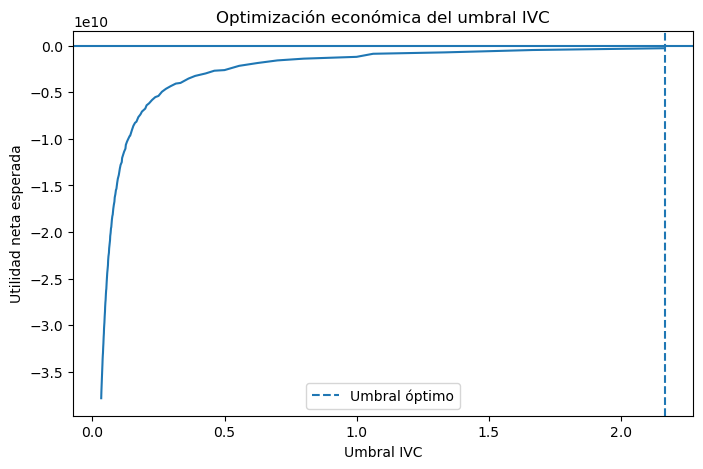

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(resultados["umbral"], resultados["utilidad_neta"])
plt.axhline(0)
plt.axvline(optimo["umbral"], linestyle="--", label="Umbral óptimo")
plt.xlabel("Umbral IVC")
plt.ylabel("Utilidad neta esperada")
plt.title("Optimización económica del umbral IVC")
plt.legend()
plt.show()
